In [2]:
import pandas as pd

df = pd.read_csv("data/restructured.csv")

In [3]:
df['full_text'] = df['story_title'] + " " + df['story_text']

In [4]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download stopwords from NLTK
#nltk.download('punkt')
#nltk.download('stopwords')

def data_preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    new_tokens = []
    for w in tokens:
        if w not in stop_words and w.isalpha():  
            stem_tokens = ps.stem(w)
            new_tokens.append(stem_tokens)
    return new_tokens


# Apply preprocessing to each message
df['full_text'] = df['full_text'].apply(data_preprocess)

# Preview the data to ensure pre-processing is as expected
df.head(10)


,roundup_title,topics,story_title,story_text,bias_label,full_text
0,"""Dream"" 50 Years Later",Civil Rights,Thousands Gather In D.C. To Mark 1963 Civil Ri...,People are assembling on the National Mall to ...,center,"[thousand, gather, mark, civil, right, march, ..."
1,"""Dream"" 50 Years Later",Civil Rights,March In Washington To Continue Focus On Civil...,Alice Long planned months ago to use vacation ...,left,"[march, washington, continu, focu, civil, righ..."
2,"""Dream"" 50 Years Later",Civil Rights,Remembering My Uncle's 'Dream',"Fifty years ago, a valiant group of people fro...",right,"[rememb, uncl, fifti, year, ago, valiant, grou..."
3,"""Good Shutdown"" in September?",Politics,"President Trump Calls for a ""Good Shutdown"" in...",President Donald Trump made a bold statement o...,right,"[presid, trump, call, good, shutdown, septemb,..."
4,"""Good Shutdown"" in September?",Politics,Trump: US ‘needs a good shutdown’,"President Trump on Tuesday called for a ""good ...",center,"[trump, us, need, good, shutdown, presid, trum..."
5,"""Good Shutdown"" in September?",Politics,Trump's frustration with budget compromise has...,Congress looks set to enact a bipartisan spend...,left,"[trump, frustrat, budget, compromis, consid, m..."
6,"""Skinny Repeal"" Motions Fails",US Senate,Obamacare repeal is dead for now. What could t...,The Senate’s effort to repeal and replace Obam...,center,"[obamacar, repeal, dead, could, mean, senat, e..."
7,"""Skinny Repeal"" Motions Fails",US Senate,Why Senate Republicans couldn’t repeal Obamacare,"In a stunning turn, Senate Republicans — in th...",left,"[senat, republican, repeal, obamacar, stun, tu..."
8,"""Skinny Repeal"" Motions Fails",US Senate,Senate Fails To Pass Motion To Proceed On ‘Ski...,Senate Majority Leader Mitch McConnell failed ...,right,"[senat, fail, pass, motion, proceed, skinni, r..."
9,"""Trump University"" Documents Unsealed",Elections,Trump University ‘Playbooks’ Unsealed in Lawsu...,Trump University gave employees detailed instr...,right,"[trump, univers, playbook, unseal, lawsuit, se..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24505 entries, 0 to 24504
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   roundup_title  24505 non-null  object
 1   topics         24505 non-null  object
 2   story_title    24505 non-null  object
 3   story_text     24505 non-null  object
 4   bias_label     24505 non-null  object
 5   full_text      24505 non-null  object
dtypes: object(6)
memory usage: 1.1+ MB


split the data and create dataframe for multi-class classification and binary classification

In [6]:
from sklearn.model_selection import train_test_split

df_multi = df.copy()

# Convert tokenized list to strings for vectorizers
df_multi['text_str'] = df_multi['full_text'].apply(lambda tokens: ' '.join(tokens))

# Train/test split once (text + label)
X_multi = df_multi['text_str']
y_multi = df_multi['bias_label']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=42, stratify=y_multi
)

# For binary classification (left vs right)
df_binary = df[df['bias_label'].isin(['left', 'right'])].copy()
df_binary['text_str'] = df_binary['full_text'].apply(lambda tokens: ' '.join(tokens))

X_binary = df_binary['text_str']
y_binary = df_binary['bias_label']

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

1a. Logisitic Regression with Bag of Words for multi-class classification (testing unigrams vs 1-3 grams)

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

def run_bow_logistic_regression(ngram_range, X_train, X_test, y_train, y_test, label=""):
    # Vectorization
    vectorizer = CountVectorizer(max_features=1000, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model training
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Evaluation
    print(f"\n--- Logistic Regression with BoW ({label}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=model.classes_,
        columns=model.classes_
    )
    print("Confusion Matrix:\n", cm)


# Run for unigrams
run_bow_logistic_regression(
    ngram_range=(1, 1),
    X_train=X_train_multi,
    X_test=X_test_multi,
    y_train=y_train_multi,
    y_test=y_test_multi,
    label="Unigrams"
)

# Run for unigrams + bigrams + trigrams
run_bow_logistic_regression(
    ngram_range=(1, 2),
    X_train=X_train_multi,
    X_test=X_test_multi,
    y_train=y_train_multi,
    y_test=y_test_multi,
    label="Unigrams+Bigrams"
)



--- Logistic Regression with BoW (Unigrams) ---
Accuracy: 41.37%
              precision    recall  f1-score   support

      center       0.37      0.33      0.35      1925
        left       0.42      0.43      0.42      2108
       right       0.44      0.47      0.46      2094

    accuracy                           0.41      6127
   macro avg       0.41      0.41      0.41      6127
weighted avg       0.41      0.41      0.41      6127

Confusion Matrix:
         center  left  right
center     630   662    633
left       581   911    616
right      479   621    994

--- Logistic Regression with BoW (Unigrams+Bigrams) ---
Accuracy: 41.81%
              precision    recall  f1-score   support

      center       0.37      0.33      0.35      1925
        left       0.42      0.44      0.43      2108
       right       0.45      0.48      0.46      2094

    accuracy                           0.42      6127
   macro avg       0.41      0.42      0.41      6127
weighted avg       0.4

1b. Logisitic Regression with Bag of Words for binary classification (testing unigrams vs 1-3 grams)

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

def run_bow_logistic_regression(ngram_range, X_train, X_test, y_train, y_test, label=""):
    # Vectorization
    vectorizer = CountVectorizer(max_features=1000, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model training
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Evaluation
    print(f"\n--- Logistic Regression with BoW ({label}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=model.classes_,
        columns=model.classes_
    )
    print("Confusion Matrix:\n", cm)


# Run for unigrams
run_bow_logistic_regression(
    ngram_range=(1, 1),
    X_train=X_train_binary,
    X_test=X_test_binary,
    y_train=y_train_binary,
    y_test=y_test_binary,
    label="Unigrams (Binary)"
)

# Run for unigrams + bigrams + trigrams
run_bow_logistic_regression(
    ngram_range=(1, 2),
    X_train=X_train_binary,
    X_test=X_test_binary,
    y_train=y_train_binary,
    y_test=y_test_binary,
    label="Unigrams+Bigrams (Binary)"
)


--- Logistic Regression with BoW (Unigrams (Binary)) ---
Accuracy: 59.11%
              precision    recall  f1-score   support

        left       0.59      0.58      0.59      2108
       right       0.59      0.60      0.59      2094

    accuracy                           0.59      4202
   macro avg       0.59      0.59      0.59      4202
weighted avg       0.59      0.59      0.59      4202

Confusion Matrix:
        left  right
left   1230    878
right   840   1254

--- Logistic Regression with BoW (Unigrams+Bigrams (Binary)) ---
Accuracy: 60.02%
              precision    recall  f1-score   support

        left       0.60      0.59      0.60      2108
       right       0.60      0.61      0.60      2094

    accuracy                           0.60      4202
   macro avg       0.60      0.60      0.60      4202
weighted avg       0.60      0.60      0.60      4202

Confusion Matrix:
        left  right
left   1252    856
right   824   1270


2a. Logisitic Regression with TF-IDF for mutli-class classification (testing unigrams vs 1-3 grams)

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

def run_tfidf_logistic_regression(ngram_range, X_train, X_test, y_train, y_test, label=""):
    # Vectorization
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model training
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Evaluation
    print(f"\n--- Logistic Regression with TF-IDF ({label}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=model.classes_,
        columns=model.classes_
    )
    print("Confusion Matrix:\n", cm)


# Run for unigrams
run_tfidf_logistic_regression(
    ngram_range=(1, 1),
    X_train=X_train_multi,
    X_test=X_test_multi,
    y_train=y_train_multi,
    y_test=y_test_multi,
    label="Unigrams (Multi-class)"
)

# Run for unigrams + bigrams + trigrams
run_tfidf_logistic_regression(
    ngram_range=(1, 2),
    X_train=X_train_multi,
    X_test=X_test_multi,
    y_train=y_train_multi,
    y_test=y_test_multi,
    label="Unigrams+Bigrams (Multi-class)"
)


--- Logistic Regression with TF-IDF (Unigrams (Multi-class)) ---
Accuracy: 41.78%
              precision    recall  f1-score   support

      center       0.38      0.32      0.35      1925
        left       0.42      0.44      0.43      2108
       right       0.45      0.49      0.47      2094

    accuracy                           0.42      6127
   macro avg       0.41      0.42      0.41      6127
weighted avg       0.42      0.42      0.42      6127

Confusion Matrix:
         center  left  right
center     622   664    639
left       564   920    624
right      457   619   1018

--- Logistic Regression with TF-IDF (Unigrams+Bigrams (Multi-class)) ---
Accuracy: 41.98%
              precision    recall  f1-score   support

      center       0.38      0.32      0.34      1925
        left       0.42      0.45      0.44      2108
       right       0.45      0.48      0.46      2094

    accuracy                           0.42      6127
   macro avg       0.42      0.42      0.4

2b. Logisitic Regression with TF-IDF for binary classification (testing unigrams vs 1-3 grams)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

def run_tfidf_logistic_regression(ngram_range, X_train, X_test, y_train, y_test, label=""):
    # Vectorization
    vectorizer = TfidfVectorizer(max_features=1000, ngram_range=ngram_range)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # Model training
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)

    # Predictions
    y_pred = model.predict(X_test_vec)

    # Evaluation
    print(f"\n--- Logistic Regression with TF-IDF ({label}) ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=model.classes_,
        columns=model.classes_
    )
    print("Confusion Matrix:\n", cm)


# Run for unigrams
run_tfidf_logistic_regression(
    ngram_range=(1, 1),
    X_train=X_train_binary,
    X_test=X_test_binary,
    y_train=y_train_binary,
    y_test=y_test_binary,
    label="Unigrams (Binary)"
)

# Run for unigrams + bigrams + trigrams
run_tfidf_logistic_regression(
    ngram_range=(1, 2),
    X_train=X_train_binary,
    X_test=X_test_binary,
    y_train=y_train_binary,
    y_test=y_test_binary,
    label="Unigrams+Bigrams (Binary)"
)


--- Logistic Regression with TF-IDF (Unigrams (Binary)) ---
Accuracy: 59.40%
              precision    recall  f1-score   support

        left       0.60      0.58      0.59      2108
       right       0.59      0.61      0.60      2094

    accuracy                           0.59      4202
   macro avg       0.59      0.59      0.59      4202
weighted avg       0.59      0.59      0.59      4202

Confusion Matrix:
        left  right
left   1229    879
right   827   1267

--- Logistic Regression with TF-IDF (Unigrams+Bigrams (Binary)) ---
Accuracy: 59.71%
              precision    recall  f1-score   support

        left       0.60      0.58      0.59      2108
       right       0.59      0.61      0.60      2094

    accuracy                           0.60      4202
   macro avg       0.60      0.60      0.60      4202
weighted avg       0.60      0.60      0.60      4202

Confusion Matrix:
        left  right
left   1226    882
right   811   1283


Logistic Regression with Word2Vec

In [15]:
# Load your data
df = pd.read_csv("data/restructured.csv")

# Combine title and text into one column
df['full_text'] = df['story_title'] + " " + df['story_text']

In [1]:
!pip install gensim
import gensim.downloader as api

# Load pretrained Word2Vec (Google News)
word2vec_model = api.load("word2vec-google-news-300")  # Takes a bit to download

  Using cached gensim-4.3.3-cp311-cp311-win_amd64.whl.metadata (8.2 kB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached smart_open-7.1.0-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp311-cp311-win_amd64.whl.metadata (6.5 kB)
Using cached gensim-4.3.3-cp311-cp311-win_amd64.whl (24.0 MB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
Using cached scipy-1.13.1-cp311-cp311-win_amd64.whl (46.2 MB)
Using cached smart_open-7.1.0-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp311-cp311-win_amd64.whl (38 kB)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[==================================================] 100.0% 1662.8/1662.8MB downloaded


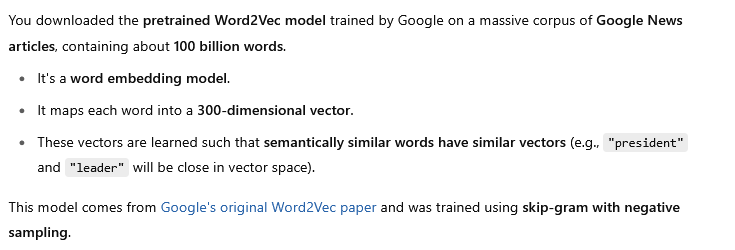

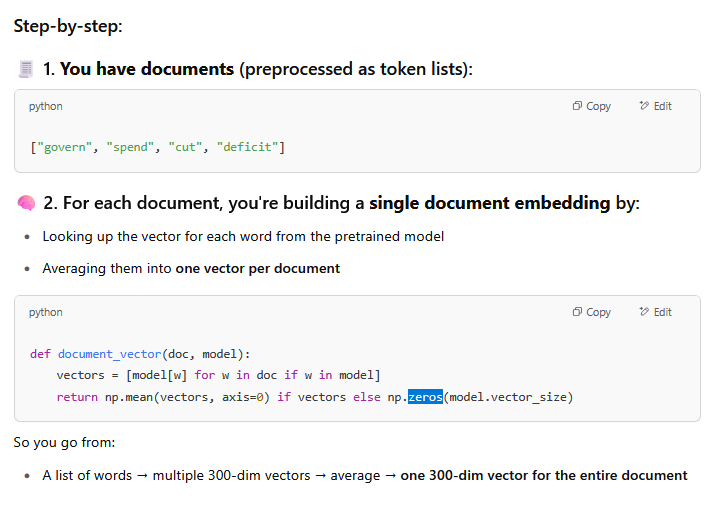

In [16]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Preprocessing function (no stemming!)
def preprocess_for_word2vec(text):
    text = text.lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    return [w for w in tokens if w.isalpha() and w not in stop_words]

# Apply preprocessing
df['w2v_tokens'] = df['full_text'].apply(preprocess_for_word2vec)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alsei\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alsei\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Get average vector of all valid tokens in a document
def document_vector(doc, model):
    valid_tokens = [token for token in doc if token in model.key_to_index]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model[token] for token in valid_tokens], axis=0)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Multi-class setup
df_multi = df.copy()
X_multi = df_multi['w2v_tokens']
y_multi = df_multi['bias_label']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=42, stratify=y_multi
)

# Convert to document vectors
X_train_vec_multi = np.array([document_vector(doc, word2vec_model) for doc in X_train_multi])
X_test_vec_multi = np.array([document_vector(doc, word2vec_model) for doc in X_test_multi])

# Train and evaluate
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train_vec_multi, y_train_multi)
y_pred_multi = model_multi.predict(X_test_vec_multi)

print("\n--- Logistic Regression + Word2Vec (Multi-class) ---")
print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_multi):.2%}")
print(classification_report(y_test_multi, y_pred_multi))
print(pd.DataFrame(confusion_matrix(y_test_multi, y_pred_multi),
                   index=model_multi.classes_, columns=model_multi.classes_))


--- Logistic Regression + Word2Vec (Multi-class) ---
Accuracy: 41.02%
              precision    recall  f1-score   support

      center       0.39      0.33      0.36      1925
        left       0.42      0.45      0.44      2108
       right       0.42      0.44      0.43      2094

    accuracy                           0.41      6127
   macro avg       0.41      0.41      0.41      6127
weighted avg       0.41      0.41      0.41      6127

        center  left  right
center     639   658    628
left       503   954    651
right      515   659    920


In [19]:
# Binary setup (left vs right only)
df_binary = df[df['bias_label'].isin(['left', 'right'])].copy()
X_binary = df_binary['w2v_tokens']
y_binary = df_binary['bias_label']

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

# Convert to document vectors
X_train_vec_binary = np.array([document_vector(doc, word2vec_model) for doc in X_train_binary])
X_test_vec_binary = np.array([document_vector(doc, word2vec_model) for doc in X_test_binary])

# Train and evaluate
model_binary = LogisticRegression(max_iter=1000)
model_binary.fit(X_train_vec_binary, y_train_binary)
y_pred_binary = model_binary.predict(X_test_vec_binary)

print("\n--- Logistic Regression + Word2Vec (Binary) ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.2%}")
print(classification_report(y_test_binary, y_pred_binary))
print(pd.DataFrame(confusion_matrix(y_test_binary, y_pred_binary),
                   index=model_binary.classes_, columns=model_binary.classes_))


--- Logistic Regression + Word2Vec (Binary) ---
Accuracy: 57.31%
              precision    recall  f1-score   support

        left       0.58      0.57      0.57      2108
       right       0.57      0.58      0.57      2094

    accuracy                           0.57      4202
   macro avg       0.57      0.57      0.57      4202
weighted avg       0.57      0.57      0.57      4202

       left  right
left   1203    905
right   889   1205


TF-IDF weighted Word2Vec (Multi Class)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

def document_vector_tfidf(doc_tokens, tfidf, model, feature_names):
    vec = np.zeros(model.vector_size)
    weight_sum = 0

    for word in doc_tokens:
        if word in model.key_to_index and word in feature_names:
            tfidf_weight = tfidf[0, feature_names[word]]
            vec += model[word] * tfidf_weight
            weight_sum += tfidf_weight

    return vec / weight_sum if weight_sum > 0 else vec


In [21]:
# Join tokens into strings for vectorizer
train_docs = X_train_multi.apply(lambda tokens: ' '.join(tokens))
test_docs = X_test_multi.apply(lambda tokens: ' '.join(tokens))

# Fit TF-IDF on training documents
tfidf_vectorizer = TfidfVectorizer()
tfidf_train = tfidf_vectorizer.fit_transform(train_docs)
tfidf_test = tfidf_vectorizer.transform(test_docs)

# Map word to column index
feature_names = {word: idx for word, idx in tfidf_vectorizer.vocabulary_.items()}

# Compute TF-IDF-weighted Word2Vec vectors
X_train_vec = np.array([
    document_vector_tfidf(doc, tfidf_train[i], word2vec_model, feature_names)
    for i, doc in enumerate(X_train_multi)
])

X_test_vec = np.array([
    document_vector_tfidf(doc, tfidf_test[i], word2vec_model, feature_names)
    for i, doc in enumerate(X_test_multi)
])

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train_multi)
y_pred = model.predict(X_test_vec)

print("\n--- Logistic Regression + TF-IDF-weighted Word2Vec (Multi-class) ---")
print(f"Accuracy: {accuracy_score(y_test_multi, y_pred):.2%}")
print(classification_report(y_test_multi, y_pred))
print(pd.DataFrame(confusion_matrix(y_test_multi, y_pred),
                   index=model.classes_, columns=model.classes_))


--- Logistic Regression + TF-IDF-weighted Word2Vec (Multi-class) ---
Accuracy: 38.52%
              precision    recall  f1-score   support

      center       0.36      0.32      0.34      1925
        left       0.40      0.42      0.41      2108
       right       0.39      0.41      0.40      2094

    accuracy                           0.39      6127
   macro avg       0.38      0.38      0.38      6127
weighted avg       0.38      0.39      0.38      6127

        center  left  right
center     623   647    655
left       536   888    684
right      556   689    849


TF-IDF weighted Word2Vec (Binary)

In [23]:
# Join tokens into strings for TF-IDF vectorizer
train_docs_bin = X_train_binary.apply(lambda tokens: ' '.join(tokens))
test_docs_bin = X_test_binary.apply(lambda tokens: ' '.join(tokens))


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Fit TF-IDF on training data
tfidf_vectorizer_bin = TfidfVectorizer()
tfidf_train_bin = tfidf_vectorizer_bin.fit_transform(train_docs_bin)
tfidf_test_bin = tfidf_vectorizer_bin.transform(test_docs_bin)

# Build a vocabulary lookup: word → column index
feature_names_bin = {word: idx for word, idx in tfidf_vectorizer_bin.vocabulary_.items()}


In [25]:
import numpy as np

def document_vector_tfidf(doc_tokens, tfidf, model, feature_names):
    vec = np.zeros(model.vector_size)
    weight_sum = 0

    for word in doc_tokens:
        if word in model.key_to_index and word in feature_names:
            tfidf_weight = tfidf[0, feature_names[word]]
            vec += model[word] * tfidf_weight
            weight_sum += tfidf_weight

    return vec / weight_sum if weight_sum > 0 else vec


In [26]:
# Create training vectors
X_train_vec_bin = np.array([
    document_vector_tfidf(doc, tfidf_train_bin[i], word2vec_model, feature_names_bin)
    for i, doc in enumerate(X_train_binary)
])

# Create test vectors
X_test_vec_bin = np.array([
    document_vector_tfidf(doc, tfidf_test_bin[i], word2vec_model, feature_names_bin)
    for i, doc in enumerate(X_test_binary)
])


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

model_bin = LogisticRegression(max_iter=1000)
model_bin.fit(X_train_vec_bin, y_train_binary)
y_pred_bin = model_bin.predict(X_test_vec_bin)

print("\n--- Logistic Regression + TF-IDF-weighted Word2Vec (Binary) ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_bin):.2%}")
print(classification_report(y_test_binary, y_pred_bin))
print(pd.DataFrame(confusion_matrix(y_test_binary, y_pred_bin),
                   index=model_bin.classes_, columns=model_bin.classes_))



--- Logistic Regression + TF-IDF-weighted Word2Vec (Binary) ---
Accuracy: 54.31%
              precision    recall  f1-score   support

        left       0.54      0.55      0.55      2108
       right       0.54      0.54      0.54      2094

    accuracy                           0.54      4202
   macro avg       0.54      0.54      0.54      4202
weighted avg       0.54      0.54      0.54      4202

       left  right
left   1158    950
right   970   1124


Custom Word2Vec

In [37]:
from gensim.models import Word2Vec

# Use your preprocessed tokenized documents
sentences = df['w2v_tokens'].tolist()

# Train a Word2Vec model
custom_w2v = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    sg=1  # 1 = Skip-gram; 0 = CBOW
)

# Save if needed
# custom_w2v.save("political_w2v.model")

In [38]:
def document_vector(doc, model):
    valid_tokens = [token for token in doc if token in model.wv.key_to_index]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[token] for token in valid_tokens], axis=0)

In [39]:
X_train_vec = np.array([document_vector(doc, custom_w2v) for doc in X_train_binary])
X_test_vec = np.array([document_vector(doc, custom_w2v) for doc in X_test_binary])

Custom Word2Vec Multi Class

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

# Convert multi-class tokenized documents to vectors
X_train_vec_multi = np.array([document_vector(doc, custom_w2v) for doc in X_train_multi])
X_test_vec_multi = np.array([document_vector(doc, custom_w2v) for doc in X_test_multi])

# Train Logistic Regression
model_multi = LogisticRegression(max_iter=1000)
model_multi.fit(X_train_vec_multi, y_train_multi)

# Predict and evaluate
y_pred_multi = model_multi.predict(X_test_vec_multi)

print("\n--- Logistic Regression + Custom Word2Vec (Multi-class) ---")
print(f"Accuracy: {accuracy_score(y_test_multi, y_pred_multi):.2%}")
print(classification_report(y_test_multi, y_pred_multi))
print(pd.DataFrame(confusion_matrix(y_test_multi, y_pred_multi),
                   index=model_multi.classes_, columns=model_multi.classes_))



--- Logistic Regression + Custom Word2Vec (Multi-class) ---
Accuracy: 39.91%
              precision    recall  f1-score   support

      center       0.38      0.27      0.32      1925
        left       0.41      0.47      0.44      2108
       right       0.40      0.44      0.42      2094

    accuracy                           0.40      6127
   macro avg       0.40      0.40      0.39      6127
weighted avg       0.40      0.40      0.39      6127

        center  left  right
center     529   700    696
left       446   991    671
right      433   736    925


Custom Word2Vec Binary

In [41]:
# Convert binary tokenized documents to vectors
X_train_vec_binary = np.array([document_vector(doc, custom_w2v) for doc in X_train_binary])
X_test_vec_binary = np.array([document_vector(doc, custom_w2v) for doc in X_test_binary])

# Train Logistic Regression
model_binary = LogisticRegression(max_iter=1000)
model_binary.fit(X_train_vec_binary, y_train_binary)

# Predict and evaluate
y_pred_binary = model_binary.predict(X_test_vec_binary)

print("\n--- Logistic Regression + Custom Word2Vec (Binary) ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.2%}")
print(classification_report(y_test_binary, y_pred_binary))
print(pd.DataFrame(confusion_matrix(y_test_binary, y_pred_binary),
                   index=model_binary.classes_, columns=model_binary.classes_))


--- Logistic Regression + Custom Word2Vec (Binary) ---
Accuracy: 56.47%
              precision    recall  f1-score   support

        left       0.57      0.57      0.57      2108
       right       0.56      0.56      0.56      2094

    accuracy                           0.56      4202
   macro avg       0.56      0.56      0.56      4202
weighted avg       0.56      0.56      0.56      4202

       left  right
left   1196    912
right   917   1177
